In [ ]:
# For the moment, no significantly interesting results
from clustering import Clustering
import matplotlib

%matplotlib inline

In [9]:
# initialis
N_CLUSTERS = 7
LEAF = "foliolo1_enves_a5"
cluster = Clustering(n_clusters=N_CLUSTERS, leaf=LEAF)

In [10]:
# clustering on raw data
cluster.load_data()
cluster.cluster(cluster.points)

silhouette score is 0.2700949013233185


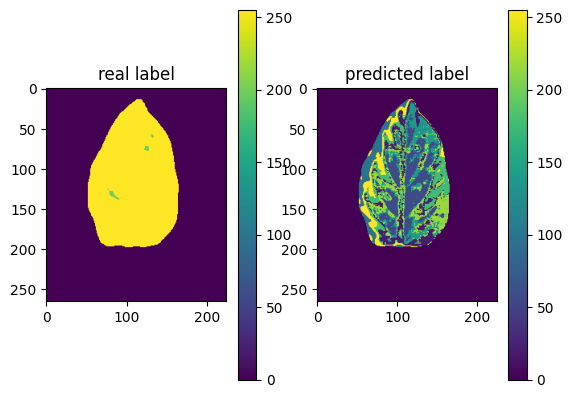

In [11]:
cluster.plot_clusters_on_leaf()

In [5]:
# raw data to 2D
cluster.load_tnse()

tnse transformed data shape :  (21814, 2)


0 (21814,)
1 (21814,)


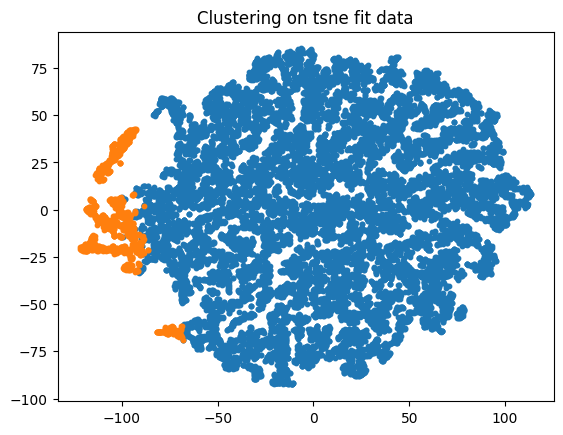

In [6]:
# with current computed label (fit on raw data)
cluster.plot_tnse()

silhouette score is 0.3800252676010132
0 (21814,)
1 (21814,)


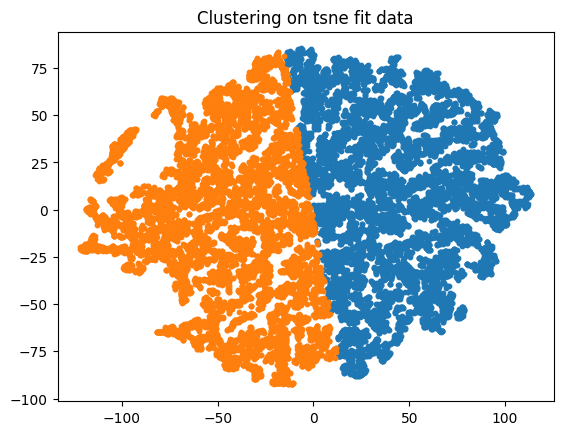

In [7]:
# train clustering on tnse data, and plot tnse with the new labels
cluster.cluster(cluster.embedded_data)
cluster.plot_tnse()

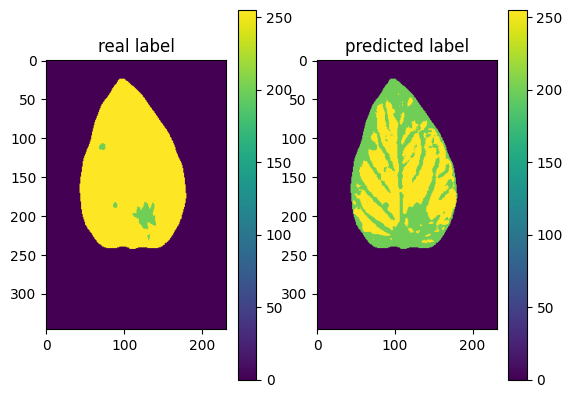

In [8]:
# What does it look like on the leaf
cluster.plot_clusters_on_leaf()

In [9]:
# cluster on raw data back
cluster.cluster(cluster.points)
import numpy as np

np.unique(cluster.kmeans.labels_)

silhouette score is 0.6883293390274048


array([0, 1], dtype=int32)

silhouette score is 0.386054128408432
0 (21814,)
1 (21814,)
2 (21814,)


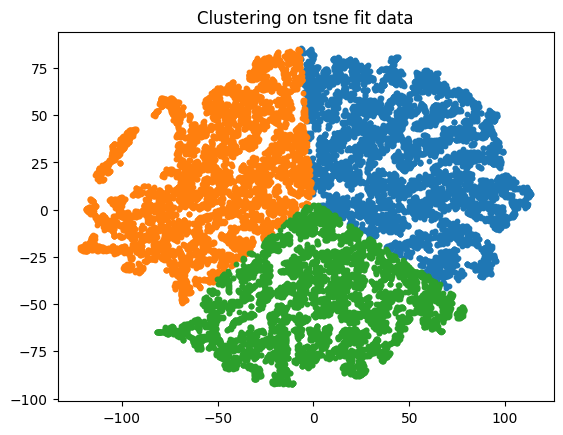

In [10]:
# what happens for clustering with 3 clusters on tnse data
cluster.n_clusters = 3
cluster.cluster(cluster.embedded_data)
cluster.plot_tnse()

silhouette score is 0.6883293390274048
0 (21814,)
1 (21814,)


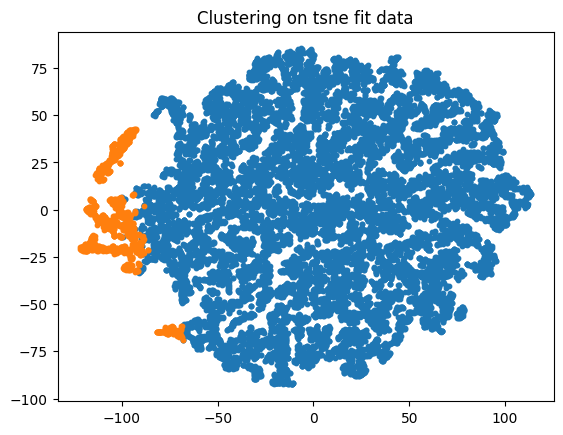

In [24]:
# back to 2 clusters
cluster.n_clusters = 2
cluster.cluster(cluster.points)
cluster.plot_tnse()

In [25]:
# We will create 3 clusters out of the minority class
n2_cluster_labels = np.copy(cluster.kmeans.labels_)

# select the minority class
class0len = len(n2_cluster_labels[n2_cluster_labels == 0])
class1len = len(n2_cluster_labels[n2_cluster_labels == 1])
min_class = 0 if class0len < class1len else 1
class1_emb_data = cluster.embedded_data[n2_cluster_labels == min_class]
# train cluster on this subdataset
cluster.n_clusters = 3
cluster.cluster(class1_emb_data)
# new_labels : just change class 1
new_labels = np.copy(n2_cluster_labels)
new_labels[n2_cluster_labels == min_class] = cluster.kmeans.labels_ + 2

silhouette score is 0.6284525394439697


(21814,)
(1234,)
(21814, 2)
0 (21814,)
2 (21814,)
3 (21814,)
4 (21814,)


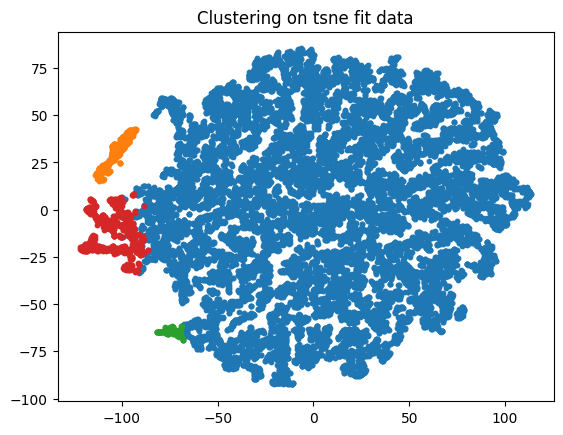

In [26]:
# plot
print(new_labels.shape)
print(cluster.kmeans.labels_.shape)
print(cluster.embedded_data.shape)
cluster.plot_tnse(labels=new_labels)

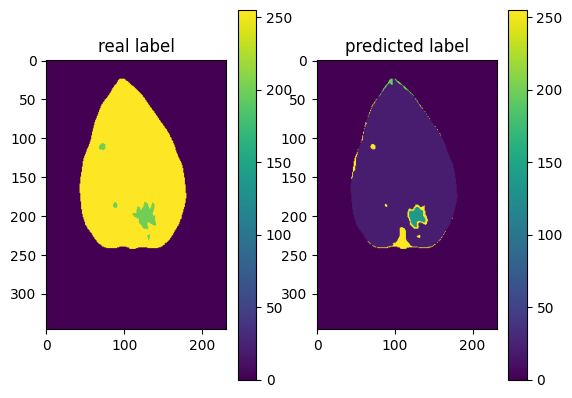

In [27]:
# Then, what does it look like on the leaf ?
cluster.plot_clusters_on_leaf(labels=new_labels)

In [ ]:
try to plot real labels on the tnse. And dist also ?